# Example: One Fire of the Intraday Production Engine

In this example, we walk a single 30-minute fire of [`production_runner.jl`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#production_runner) end-to-end. The runner is the cron-driven script that operates the intraday engine; each fire pulls the latest bar, updates SIM parameters via [`ewls_update!`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#ewls_update!), runs the regime-aware allocator, and splits proposed trades into auto-execute (Alpaca submit) versus queued for human review. We reproduce that pipeline here on a fabricated trading day so we can inspect every state transition, then loop the same step across all 13 bars to produce the audit tape that the [Core EveningReview notebook](eCornell-AI-Finance-S4-Example-Core-EveningReview-May-2026.ipynb) reads.

> __Learning Objectives:__
>
> * __Walk one engine fire end-to-end:__ Trace bar arrival, EWLS update, sentiment and regime computation, allocator solve, proposed-trade construction, news-severity join, and the per-trade gate evaluation that produces the auto/queue split.
> * __Compare three proposed-trade baskets through the gate split:__ Pump baskets that exercise each gate (concentration cap, position size, news severity, turnover) through [`split_intraday_trades`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#split_intraday_trades) and tabulate which trades clear and which route to the queue.
> * __Build the day's audit tape and read it:__ Loop the engine step over all 13 fires of a synthetic trading day, persist the audit-tape entries the EveningReview notebook will consume, and surface per-hour wealth, drawdown, and queued-trade counts.

Let's run one fire.

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

### Constants


In [2]:
# Intraday cadence (matches production-config.toml)
BAR_MINUTES = 30
B0 = 10_000.0
HALF_LIFE_CALENDAR_DAYS = 63.0
PRIOR_WEIGHT_CALENDAR_DAYS = 63.0

# Compliance gates (matches the [Compliance] section of production-config.toml)
CONCENTRATION_CAP = 0.30
POSITION_SIZE_LIMIT = 1500.0
TURNOVER_LIMIT = 0.20
NEWS_SEVERITY_THRESHOLD = 0.7

# Fixture knobs for the synthetic May 11 trading day
FIXTURE_DATE = Date(2026, 5, 11)
FIXTURE_SEED = 20260511
MARKET_SHOCK_BAR = 4               # ~11:00 vendor-warning bar
MARKET_SHOCK_GROWTH = -0.020       # -2.0% on the index at the shock bar
# News severity overrides (high-severity demo flags). Tickers not
# listed default to 0.0 severity. Should be a subset of the S1 basket.
NEWS_FLAGS = Dict("AAPL" => 0.45, "MSFT" => 0.81)


Dict{String, Float64} with 2 entries:
  "MSFT" => 0.81
  "AAPL" => 0.45

Load the [Session 1 frozen SIM calibration](../session-1/eCornell-AI-Finance-S1-Example-Optional-MinVarianceConstruction-May-2026.ipynb) and build today's fixture: a 13-bar SPY index path with the 11:00 shock from the Introduction, a per-ticker price matrix derived via SIM, an EWLS state per ticker seeded from the frozen calibration, and a per-ticker news-severity dictionary mocking the latest hourly news artifact.

In the code block below, we return: `tickers::Vector{String}`, `sim_params_frozen::Dict{String,Tuple{Float64,Float64,Float64}}`, `ewls_states::Dict{String,MyEWLSState}`, `spy::Vector{Float64}` (length $B + 1$), `prices::Dict{String,Vector{Float64}}` (per-ticker, length $B + 1$), `news_severity::Dict{String,Float64}`, `Δt::Float64`, and `n_bars::Int`.

In [3]:
tickers, sim_params_frozen, ewls_states, spy, prices, news_severity, Δt, n_bars = let
    Random.seed!(FIXTURE_SEED);

    # --- Step 1: Load the frozen SIM calibration and ticker universe from Session 1 ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    tickers = minvar["my_tickers"]::Vector{String};
    sim_estimates = minvar["sim_estimates"];
    σ_m = Float64(minvar["sigma_market"]);
    by_ticker = Dict(e.ticker => e for e in sim_estimates);
    sim_params_frozen = Dict{String,Tuple{Float64,Float64,Float64}}(
        t => (Float64(by_ticker[t].α), Float64(by_ticker[t].β), Float64(by_ticker[t].σ_ε))
        for t in tickers);

    # --- Step 2: Convert daily SIM units to intraday bar units ---
    n_bars = bars_per_day(BAR_MINUTES);
    Δt = intraday_dt(BAR_MINUTES);
    h_bars = intraday_half_life(HALF_LIFE_CALENDAR_DAYS, BAR_MINUTES);
    pw_bars = intraday_half_life(PRIOR_WEIGHT_CALENDAR_DAYS, BAR_MINUTES);

    # --- Step 3: Simulate today's SPY 30-min path with a midday shock at MARKET_SHOCK_BAR ---
    σ_per_bar = σ_m * sqrt(Δt);
    spy = ones(n_bars + 1) .* 100.0;
    for t in 1:n_bars
        z = randn();
        gm_t = σ_per_bar * z + (t == MARKET_SHOCK_BAR ? MARKET_SHOCK_GROWTH : 0.0);
        spy[t + 1] = spy[t] * exp(gm_t);
    end

    # --- Step 4: Simulate per-ticker prices via the frozen SIM ---
    prices = Dict{String,Vector{Float64}}();
    for t in tickers
        α0, β0, σε0 = sim_params_frozen[t];
        σε_per_bar = σε0 * sqrt(Δt);
        α_per_bar = α0 * Δt;
        px = ones(n_bars + 1) .* 100.0;
        for b in 1:n_bars
            gm_t = log(spy[b + 1] / spy[b]);
            ε = σε_per_bar * randn();
            px[b + 1] = px[b] * exp(α_per_bar + β0 * gm_t + ε);
        end
        prices[t] = px;
    end

    # --- Step 5: Seed an EWLS state per ticker from the frozen calibration ---
    ewls_states = Dict{String,MyEWLSState}(
        t => ewls_init(sim_params_frozen[t]...; half_life = h_bars, prior_weight = pw_bars)
        for t in tickers);

    # --- Step 6: Mock today's news-severity dict from NEWS_FLAGS overrides ---
    news_severity = Dict{String,Float64}(t => 0.0 for t in tickers);
    for (t, sev) in NEWS_FLAGS
        haskey(news_severity, t) && (news_severity[t] = sev);
    end

    println("Fixture ready: $(length(tickers)) tickers, $(n_bars) bars, shock at bar $(MARKET_SHOCK_BAR).")
    println("Tickers: ", join(tickers, ", "))
    println("News severity: ", news_severity)
    tickers, sim_params_frozen, ewls_states, spy, prices, news_severity, Δt, n_bars
end;

Fixture ready: 20 tickers, 13 bars, shock at bar 4.


Tickers: VZ, T, MCD, PG, KO, PEP, WMT, XOM, CVX, JPM, BRK.B, JNJ, MRK, HON, UPS, AAPL, MSFT, APD, AMT, NEE
News severity: 

Dict("JPM" => 0.0, "MSFT" => 0.81, "APD" => 0.0, "VZ" => 0.0, "T" => 0.0, "MRK" => 0.0, "HON" => 0.0, "NEE" => 0.0, "PG" => 0.0, "JNJ" => 0.0, "MCD" => 0.0, "XOM" => 0.0, "CVX" => 0.0, "WMT" => 0.0, "PEP" => 0.0, "BRK.B" => 0.0, "UPS" => 0.0, "AAPL" => 0.45, "KO" => 0.0, "AMT" => 0.0)


___
## Task 1: One Engine Fire End-to-End
In this task, we walk one cron fire bar-by-bar, focusing on the shock bar (~11:00) so the regime change is visible. The pipeline is: fetch bar, [`ewls_update!`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#ewls_update!) per ticker, recompute sentiment and lambda, classify regime via [`classify_regime`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#classify_regime), pick elasticity via [`compute_adaptive_eta`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#compute_adaptive_eta), solve the allocator weights, build proposed trades from the delta to current positions, join news severity, and call [`split_intraday_trades`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#split_intraday_trades) for the auto/queue split.

> __What should we see?__
>
> Before the shock, EWLS estimates barely move and the allocator's target weights are close to the prior fire's. At the shock bar, EWLS pulls the affected ticker's $\hat\beta$ down (the ticker fell more than its frozen $\beta$ predicts), the sentiment series turns negative, and the regime flips toward bearish. The allocator responds by reducing concentration in the affected ticker, generating a meaningful sell proposal that may cross the gates.

The cell-bound result is `fire_record::NamedTuple` capturing every state transition for the shock bar (so we can read what the engine saw and decided), plus a `pretty_table` of the proposed trades with their gate verdicts.

In [4]:
fire_record = let
    # --- Step 1: Replay bars 1..MARKET_SHOCK_BAR - 1 to seed the rolling intraday buffer ---
    spy_buffer = Float64[];
    spy_timestamps = DateTime[];
    open_dt = DateTime(FIXTURE_DATE) + Hour(9) + Minute(30);
    bar_dt(b) = open_dt + Minute(BAR_MINUTES * (b - 1));
    for b in 1:(MARKET_SHOCK_BAR - 1)
        push!(spy_buffer, spy[b + 1]);
        push!(spy_timestamps, bar_dt(b));
        if b >= 2
            gm_t = (1.0 / Δt) * log(spy[b + 1] / spy[b]);
            for t in tickers
                gi_t = (1.0 / Δt) * log(prices[t][b + 1] / prices[t][b]);
                ewls_update!(ewls_states[t], gi_t, gm_t);
            end
        end
    end
    β_pre = Dict(t => ewls_states[t].β for t in tickers);

    # --- Step 2: Process the shock bar — same code path the runner takes on every fire ---
    b = MARKET_SHOCK_BAR;
    push!(spy_buffer, spy[b + 1]);
    push!(spy_timestamps, bar_dt(b));
    gm_t = (1.0 / Δt) * log(spy[b + 1] / spy[b]);
    for t in tickers
        gi_t = (1.0 / Δt) * log(prices[t][b + 1] / prices[t][b]);
        ewls_update!(ewls_states[t], gi_t, gm_t);
    end
    β_post = Dict(t => ewls_states[t].β for t in tickers);

    # --- Step 3: Sentiment, λ, and regime from the rolling intraday buffer ---
    sentiment = compute_live_sentiment(spy_buffer);
    ema_s = compute_ema(spy_buffer; window = 21);
    ema_l = compute_ema(spy_buffer; window = 63);
    λ_series = compute_lambda(ema_s, ema_l; G = 10.0);
    λ_eff = λ_series[end];
    regime = classify_regime(λ_eff);
    η = compute_adaptive_eta(λ_eff);

    # --- Step 4: Allocator with current EWLS-tracked SIM params ---
    sim_params_now = Dict{String,Tuple{Float64,Float64,Float64}}(
        t => (ewls_states[t].α, ewls_states[t].β, ewls_states[t].σ_ε) for t in tickers);
    gm_raw = compute_market_growth(spy_buffer; Δt = Δt);
    gm_smoothed = compute_ema(gm_raw; window = 10);
    gm_t_value = isempty(gm_smoothed) ? 0.0 : gm_smoothed[end];
    γ = compute_preference_weights(sim_params_now, tickers, gm_t_value, λ_eff);
    γ_sum = sum(γ);
    target_weights = γ_sum > 0 ? γ ./ γ_sum : ones(length(tickers)) ./ length(tickers);

    # --- Step 5: Build proposed trades from delta(target → current positions) ---
    current_prices = [prices[t][b + 1] for t in tickers];
    # Start the day with a deliberately-skewed allocation so the bar-4 fire
    # has a visible rebalance to propose (β-heavy on the first three names,
    # underweight on the rest). In production these would be the prior fire's
    # holdings persisted in production-state.jld2.
    flagged_idx = [findfirst(==(t), tickers) for t in keys(NEWS_FLAGS)
        if findfirst(==(t), tickers) !== nothing];
    skew = ones(length(tickers));
    for i in flagged_idx
        skew[i] = 1.6;  # overweight the news-flagged tickers so the rebalance hits them
    end
    skew ./= sum(skew) ./ length(tickers);  # rescale so mean(skew) = 1.0
    current_shares = [round(B0 / length(tickers) * skew[k] / current_prices[k], digits = 0) for k in 1:length(tickers)];
    current_cash = B0 - sum(current_shares .* current_prices);
    portfolio_value = sum(current_shares .* current_prices) + current_cash;
    target_dollar = target_weights .* portfolio_value;
    target_shares = target_dollar ./ current_prices;
    delta_shares = round.(Int, target_shares .- current_shares);

    proposed_trades = NamedTuple[];
    for (k, t) in enumerate(tickers)
        delta_shares[k] == 0 && continue;
        push!(proposed_trades, (
            ticker = t, qty = abs(delta_shares[k]),
            side = delta_shares[k] > 0 ? :buy : :sell,
            dollar_value = Float64(delta_shares[k]) * current_prices[k],
            post_trade_weight = abs(target_dollar[k]) / max(portfolio_value, 1e-8),
        ));
    end

    # --- Step 6: Gate split using the production-config thresholds ---
    gate_config = build_compliance_config(
        concentration_cap = CONCENTRATION_CAP,
        position_size_limit = POSITION_SIZE_LIMIT,
        turnover_limit = TURNOVER_LIMIT);
    gate_config["news_severity_queue_threshold"] = NEWS_SEVERITY_THRESHOLD;
    gate_config["portfolio_value"] = portfolio_value;
    snaps = Dict{String,NamedTuple}(t => (news_severity = news_severity[t],) for t in tickers);
    engine_snapshot = Dict{String,Any}(
        "eta" => η, "lambda_eff" => λ_eff, "sentiment" => sentiment,
        "regime" => string(regime), "bar" => b);
    auto, queued = split_intraday_trades(proposed_trades, snaps, gate_config,
        bar_dt(b), engine_snapshot);

    # --- Step 7: Tabulate the proposed trades and their per-trade gate verdicts ---
    rows = NamedTuple[];
    auto_set = Set([(t.ticker, t.side, t.qty) for t in auto]);
    for tr in proposed_trades
        cleared = (tr.ticker, tr.side, tr.qty) in auto_set;
        q = findfirst(q -> q.ticker == tr.ticker && q.side == tr.side && q.qty == tr.qty, queued);
        violations = q === nothing ? "" : join(string.(queued[q].gate_violations), ", ");
        push!(rows, (Ticker = tr.ticker, Side = tr.side == :buy ? "BUY" : "SELL",
            Qty = tr.qty, Dollars = "\$$(round(tr.dollar_value, digits=0))",
            Post_w = "$(round(100 * tr.post_trade_weight, digits=1))%",
            News_sev = round(news_severity[tr.ticker], digits = 2),
            Verdict = cleared ? "AUTO" : "QUEUE",
            Violations = violations));
    end
    df = DataFrame(rows);

    println("Bar $(b) at $(bar_dt(b)) — sentiment = $(round(sentiment, digits=3)), " *
        "λ = $(round(λ_eff, digits=3)), regime = $(regime), η = $(round(η, digits=2))");
    println("Portfolio value: \$$(round(portfolio_value, digits=2)). " *
        "Proposed: $(length(proposed_trades)) trades. Auto: $(length(auto)). Queue: $(length(queued)).");
    println();
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    (bar = b, sentiment = sentiment, lambda = λ_eff, regime = regime, eta = η,
     β_pre = β_pre, β_post = β_post, target_weights = target_weights,
     proposed = proposed_trades, auto = auto, queued = queued,
     portfolio_value = portfolio_value)
end;

Bar 4 at 2026-05-11T11:00:00 — sentiment = 0.0, λ = 0.069, regime = neutral, η = 4.71


Portfolio value: $10000.0. Proposed: 11 trades. Auto: 10. Queue: 1.

 -------- -------- ------- --------- -------- ---------- --------- ---------------
  Ticker     Side     Qty   Dollars   Post_w   News_sev   Verdict      Violations 
  String   String   Int64    String   String    Float64    String          String 
 -------- -------- ------- --------- -------- ---------- --------- ---------------
     MCD      BUY       1    $105.0     5.0%        0.0      AUTO
      KO      BUY       1    $111.0     5.0%        0.0      AUTO
     PEP      BUY       1    $106.0     5.0%        0.0      AUTO
     XOM      BUY       1     $88.0     5.0%        0.0      AUTO
   BRK.B      BUY       1    $110.0     5.0%        0.0      AUTO
     JNJ      BUY       1    $106.0     5.0%        0.0      AUTO
     HON      BUY       1    $105.0     5.0%        0.0      AUTO
    AAPL     SELL       2   $-220.0     5.0%       0.45      AUTO
    MSFT     SELL       3   $-280.0     5.0%       0.81     QUEUE   new

___
## Task 2: Three Baskets Through the Gate Split
In this task, we exercise [`split_intraday_trades`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#split_intraday_trades) with three hand-crafted baskets that each stress a different gate. Basket A contains only small in-tolerance trades (everything auto-executes); Basket B includes a single oversized buy that breaches the concentration cap; Basket C's total turnover exceeds the per-fire cap, which routes every trade to the queue under the portfolio-level rule. Tabulating the verdicts side-by-side makes the gate semantics concrete.

> __What should we see?__
>
> Basket A produces all-AUTO verdicts. Basket B produces one QUEUE row (the oversized trade) and AUTO for the rest. Basket C produces all QUEUE rows, each tagged with `:turnover_limit` because the portfolio-level cap was breached before any per-trade gate evaluation could matter.

The cell-bound result is `basket_results::Vector{NamedTuple}` with one entry per basket capturing the `(auto_n, queue_n, total_turnover_pct)` summary.

In [5]:
basket_results = let
    portfolio_value = 10_000.0;
    gate_config = build_compliance_config(
        concentration_cap = CONCENTRATION_CAP,
        position_size_limit = POSITION_SIZE_LIMIT,
        turnover_limit = TURNOVER_LIMIT);
    gate_config["news_severity_queue_threshold"] = NEWS_SEVERITY_THRESHOLD;
    gate_config["portfolio_value"] = portfolio_value;
    no_news = Dict{String,NamedTuple}(
        t => (news_severity = 0.0,) for t in ["AAPL", "MSFT", "NVDA", "AMZN"]);
    snap_engine = Dict{String,Any}("eta" => 2.0, "regime" => "neutral");
    ts = DateTime(FIXTURE_DATE) + Hour(11);

    # --- Basket A: small in-tolerance trades — all auto (turnover < 20% cap) ---
    basket_a = [
        (ticker = "AAPL", qty = 3, side = :buy,
            dollar_value = 450.0, post_trade_weight = 0.18),
        (ticker = "MSFT", qty = 2, side = :buy,
            dollar_value = 560.0, post_trade_weight = 0.18),
        (ticker = "AMZN", qty = 3, side = :sell,
            dollar_value = -450.0, post_trade_weight = 0.10),
    ];

    # --- Basket B: one oversized buy — concentration-cap breach on NVDA ---
    basket_b = [
        (ticker = "AAPL", qty = 3, side = :buy,
            dollar_value = 450.0, post_trade_weight = 0.18),
        (ticker = "NVDA", qty = 12, side = :buy,
            dollar_value = 1100.0, post_trade_weight = 0.42),
        (ticker = "AMZN", qty = 3, side = :sell,
            dollar_value = -450.0, post_trade_weight = 0.10),
    ];

    # --- Basket C: total turnover exceeds 20% cap — all queue ---
    basket_c = [
        (ticker = "AAPL", qty = 6, side = :buy,
            dollar_value = 900.0, post_trade_weight = 0.22),
        (ticker = "MSFT", qty = 4, side = :buy,
            dollar_value = 1120.0, post_trade_weight = 0.18),
        (ticker = "NVDA", qty = 5, side = :buy,
            dollar_value = 700.0, post_trade_weight = 0.15),
    ];

    baskets = [("A: small", basket_a), ("B: concentration", basket_b),
               ("C: turnover", basket_c)];
    rows = NamedTuple[];
    results = NamedTuple[];

    for (label, basket) in baskets
        auto, queued = split_intraday_trades(basket, no_news, gate_config, ts, snap_engine);
        total_turnover = sum(abs(t.dollar_value) for t in basket; init = 0.0);
        push!(results, (label = label, auto_n = length(auto), queue_n = length(queued),
            turnover_pct = round(100 * total_turnover / portfolio_value, digits = 1)));
        for tr in basket
            q = findfirst(q -> q.ticker == tr.ticker && q.side == tr.side &&
                q.qty == tr.qty, queued);
            violations = q === nothing ? "" : join(string.(queued[q].gate_violations), ", ");
            push!(rows, (Basket = label, Ticker = tr.ticker,
                Side = tr.side == :buy ? "BUY" : "SELL",
                Qty = tr.qty,
                Dollars = "\$$(round(tr.dollar_value, digits=0))",
                Post_w = "$(round(100 * tr.post_trade_weight, digits=1))%",
                Verdict = q === nothing ? "AUTO" : "QUEUE",
                Violations = violations));
        end
    end

    println("Basket-level summary:");
    for r in results
        println("  $(r.label): auto = $(r.auto_n), queue = $(r.queue_n), " *
            "turnover = $(r.turnover_pct)% of \$$(Int(portfolio_value)) portfolio");
    end
    println();
    pretty_table(DataFrame(rows); backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
    results
end;

Basket-level summary:


  A: small: auto = 3, queue = 0, turnover = 14.6% of $10000 portfolio


  B: concentration: auto = 2, queue = 1, turnover = 20.0% of $10000 portfolio
  C: turnover: auto = 0, queue = 3, turnover = 27.2% of $10000 portfolio

 ------------------ -------- -------- ------- --------- -------- --------- -------------------
            Basket   Ticker     Side     Qty   Dollars   Post_w   Verdict          Violations 
            String   String   String   Int64    String   String    String              String 
 ------------------ -------- -------- ------- --------- -------- --------- -------------------
          A: small     AAPL      BUY       3    $450.0    18.0%      AUTO
          A: small     MSFT      BUY       2    $560.0    18.0%      AUTO
          A: small     AMZN     SELL       3   $-450.0    10.0%      AUTO
  B: concentration     AAPL      BUY       3    $450.0    18.0%      AUTO
  B: concentration     NVDA      BUY      12   $1100.0    42.0%     QUEUE   concentration_cap
  B: concentration     AMZN     SELL       3   $-450.0    10.0%      AUTO
    

___
## Task 3: Today's Audit Tape
In this task, we loop the engine step over all 13 fires of the synthetic May 11 trading day, append one audit-tape entry per fire, and persist the tape to `data/intraday-tape/tape-2026-05-11.jld2`. Then we read the tape back and produce two pictures: a per-fire wealth and drawdown trace, and a per-hour count of auto vs queued trades. This is exactly the artifact the [Core EveningReview notebook](eCornell-AI-Finance-S4-Example-Core-EveningReview-May-2026.ipynb) consumes.

> __What should we see?__
>
> Wealth tracks SPY through the morning, dips at the shock bar, and partially recovers. Drawdown opens at the shock and peaks an hour or two later. Queued trades cluster around the shock fires (when the allocator wants to make large rebalancing moves) and around the news-flagged ticker; auto-executed trades dominate the calmer afternoon fires.

The cell-bound result is `tape::Vector{NamedTuple}` (one entry per fire) and the two figures display inline. The tape is also written to disk so the EveningReview notebook can read it without re-running this cell.

Wrote 13-entry tape to /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-4/data/intraday-tape/tape-2026-05-11.jld2.


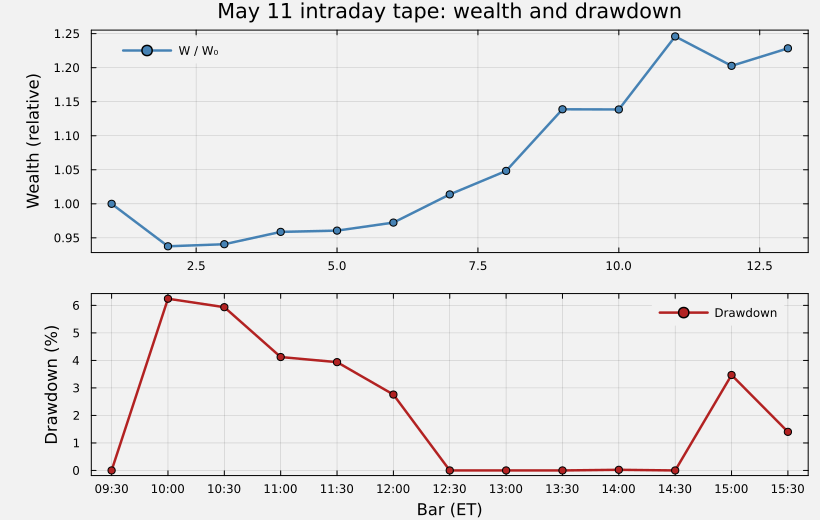

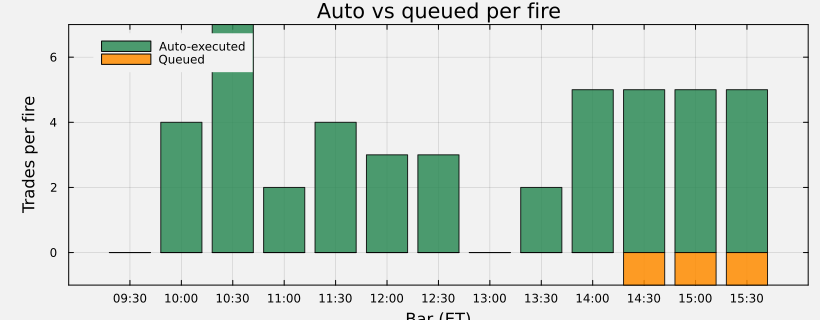

Day summary: terminal W/W₀ = 1.228, max drawdown = 6.2%, 45 auto, 3 queued.


In [6]:
tape = let
    # --- Step 1: Reset EWLS so we replay all 13 bars from the start ---
    h_bars = intraday_half_life(HALF_LIFE_CALENDAR_DAYS, BAR_MINUTES);
    pw_bars = intraday_half_life(PRIOR_WEIGHT_CALENDAR_DAYS, BAR_MINUTES);
    states = Dict{String,MyEWLSState}(
        t => ewls_init(sim_params_frozen[t]...; half_life = h_bars, prior_weight = pw_bars)
        for t in tickers);
    open_dt = DateTime(FIXTURE_DATE) + Hour(9) + Minute(30);
    bar_dt(b) = open_dt + Minute(BAR_MINUTES * (b - 1));

    # --- Step 2: Track current positions/cash; initialize equal-weight at the open ---
    K = length(tickers);
    open_prices = [prices[t][2] for t in tickers];
    current_shares = [round(B0 / K / open_prices[k], digits = 0) for k in 1:K];
    current_cash = B0 - sum(current_shares .* open_prices);
    peak_wealth = B0;
    spy_buffer = Float64[];
    tape = NamedTuple[];

    gate_config_base = build_compliance_config(
        concentration_cap = CONCENTRATION_CAP,
        position_size_limit = POSITION_SIZE_LIMIT,
        turnover_limit = TURNOVER_LIMIT);
    gate_config_base["news_severity_queue_threshold"] = NEWS_SEVERITY_THRESHOLD;
    snaps = Dict{String,NamedTuple}(t => (news_severity = news_severity[t],) for t in tickers);

    # --- Step 3: Loop the engine step over each bar of the day ---
    for b in 1:n_bars
        push!(spy_buffer, spy[b + 1]);
        if b >= 2
            gm_t = (1.0 / Δt) * log(spy[b + 1] / spy[b]);
            for t in tickers
                gi_t = (1.0 / Δt) * log(prices[t][b + 1] / prices[t][b]);
                ewls_update!(states[t], gi_t, gm_t);
            end
        end

        sentiment = compute_live_sentiment(spy_buffer);
        ema_s = compute_ema(spy_buffer; window = 21);
        ema_l = compute_ema(spy_buffer; window = 63);
        λ_series = compute_lambda(ema_s, ema_l; G = 10.0);
        λ_eff = isempty(λ_series) ? 0.0 : λ_series[end];
        regime = classify_regime(λ_eff);
        η = compute_adaptive_eta(λ_eff);

        sim_now = Dict{String,Tuple{Float64,Float64,Float64}}(
            t => (states[t].α, states[t].β, states[t].σ_ε) for t in tickers);
        gm_t_inner = if length(spy_buffer) >= 2
            gm_raw_inner = compute_market_growth(spy_buffer; Δt = Δt);
            length(gm_raw_inner) >= 1 ? compute_ema(gm_raw_inner; window = 10)[end] : 0.0
        else
            0.0
        end;
        γ = compute_preference_weights(sim_now, tickers, gm_t_inner, λ_eff);
        γ_sum = sum(γ);
        target_weights = γ_sum > 0 ? γ ./ γ_sum : ones(K) ./ K;

        cur_prices = [prices[t][b + 1] for t in tickers];
        portfolio_value = sum(current_shares .* cur_prices) + current_cash;
        peak_wealth = max(peak_wealth, portfolio_value);
        drawdown = (peak_wealth - portfolio_value) / peak_wealth;
        target_dollar = target_weights .* portfolio_value;
        target_shares = target_dollar ./ cur_prices;
        delta = round.(Int, target_shares .- current_shares);

        proposed = NamedTuple[];
        for (k, t) in enumerate(tickers)
            delta[k] == 0 && continue;
            push!(proposed, (
                ticker = t, qty = abs(delta[k]),
                side = delta[k] > 0 ? :buy : :sell,
                dollar_value = Float64(delta[k]) * cur_prices[k],
                post_trade_weight = abs(target_dollar[k]) / max(portfolio_value, 1e-8)));
        end

        gate_config = copy(gate_config_base);
        gate_config["portfolio_value"] = portfolio_value;
        engine_snapshot = Dict{String,Any}(
            "eta" => η, "lambda_eff" => λ_eff, "regime" => string(regime),
            "sentiment" => sentiment, "bar" => b);
        auto, queued = split_intraday_trades(proposed, snaps, gate_config,
            bar_dt(b), engine_snapshot);

        # Apply auto trades to current positions (simulating the Alpaca submit + fill)
        for tr in auto
            kk = findfirst(==(tr.ticker), tickers);
            kk === nothing && continue;
            sgn = tr.side == :buy ? 1 : -1;
            current_shares[kk] += sgn * tr.qty;
            current_cash -= sgn * tr.qty * cur_prices[kk];
        end

        push!(tape, (fire_time = bar_dt(b), bar = b,
            sentiment = sentiment, lambda_eff = λ_eff, regime = regime, eta = η,
            wealth = portfolio_value, drawdown = drawdown,
            auto_n = length(auto), queued_n = length(queued)));
    end

    # --- Step 4: Persist the tape to disk for the EveningReview notebook ---
    tape_path = joinpath(_PATH_TO_TAPE, "tape-2026-05-11.jld2");
    save_results(tape_path, Dict("entries" => tape));
    println("Wrote $(length(tape))-entry tape to $(tape_path).");

    # --- Step 5: Plot wealth and drawdown across the day ---
    bar_labels = [Dates.format(e.fire_time, "HH:MM") for e in tape];
    bar_idx = 1:length(tape);
    p1 = plot(bar_idx, [e.wealth / B0 for e in tape];
        lw = 2.5, c = :steelblue, marker = :circle, ms = 4,
        label = "W / W₀", ylabel = "Wealth (relative)",
        title = "May 11 intraday tape: wealth and drawdown");
    p2 = plot(bar_idx, [100 * e.drawdown for e in tape];
        lw = 2.5, c = :firebrick, marker = :circle, ms = 4,
        label = "Drawdown", ylabel = "Drawdown (%)", xlabel = "Bar (ET)",
        xticks = (bar_idx, bar_labels));
    plot!(p1, bg = "gray95", framestyle = :box, fg_legend = :transparent);
    plot!(p2, bg = "gray95", framestyle = :box, fg_legend = :transparent);
    display(plot(p1, p2; layout = grid(2, 1, heights = [0.55, 0.45]),
        size = (820, 520), left_margin = 8Plots.mm));

    # --- Step 6: Plot auto vs queued counts per bar ---
    p3 = bar(bar_idx, [e.auto_n for e in tape];
        c = :seagreen, alpha = 0.85, label = "Auto-executed",
        ylabel = "Trades per fire", title = "Auto vs queued per fire",
        xlabel = "Bar (ET)", xticks = (bar_idx, bar_labels));
    bar!(p3, bar_idx, [-e.queued_n for e in tape];
        c = :darkorange, alpha = 0.85, label = "Queued");
    plot!(p3, bg = "gray95", framestyle = :box, fg_legend = :transparent,
        size = (820, 320), left_margin = 8Plots.mm);
    display(p3);

    println("Day summary: terminal W/W₀ = $(round(tape[end].wealth / B0, digits = 3)), " *
        "max drawdown = $(round(100 * maximum(e.drawdown for e in tape), digits = 1))%, " *
        "$(sum(e.auto_n for e in tape)) auto, $(sum(e.queued_n for e in tape)) queued.")
    tape
end;

___
## Summary
This example walked one cron fire of the intraday production engine end-to-end on a synthetic May 11 trading day, exercised the gate split with three crafted baskets, and looped the engine step across the full day to produce the audit tape that the EveningReview notebook consumes. The tape lives at `data/intraday-tape/tape-2026-05-11.jld2`.

> __Key Takeaways:__
>
> * __One fire is a closed loop:__ Bar arrival, EWLS update, sentiment and regime computation, allocator solve, gate split, and audit-tape append happen on every cron call. Persisting the EWLS state across fires is what makes the loop online.
> * __Gates have distinct intents:__ Concentration cap and position size are per-trade safety rails, news severity is a contextual override, and the turnover limit is a portfolio-level brake. A single proposal can fail multiple gates; the queue records the union of violations for review.
> * __The tape is the day's compliance record:__ One audit entry per fire is the artifact the desk reads at 7pm. Wealth, drawdown, auto vs queued counts per fire are the scorecard; the queue file is the work item list.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The example uses synthetic intraday bars, a frozen S1 calibration, and mocked news severity; production deployment requires real bar feeds, real news scoring, and additional regulatory and operational controls.

___